## Dataset YOLO

In [ ]:
!pip install -q kaggle

In [ ]:
import os

os.environ['KAGGLE_API_TOKEN'] = 'KGAT_eeb079978ca0589985c7cd8bd873d116'

In [ ]:
!kaggle datasets download -d hussainnasirkhan/fire-and-smoke-detection-dataset

Dataset URL: https://www.kaggle.com/datasets/hussainnasirkhan/fire-and-smoke-detection-dataset
License(s): MIT
100% 3.08G/3.08G [02:44<00:00, 20.1MB/s]



In [ ]:
!unzip fire-and-smoke-detection-dataset.zip

Выходные данные были обрезаны до нескольких последних строк (5000).
  inflating: Fire-and-Smoke-Detection-Dataset/Fire-and-Smoke-Detection-Dataset/dataset/train/labels/youtube-34_jpg.rf.c9f8a0eae9c649d832d5a858e577a6d3.txt  
  inflating: Fire-and-Smoke-Detection-Dataset/Fire-and-Smoke-Detection-Dataset/dataset/train/labels/youtube-34_jpg.rf.e6f154bb539745ff2777723b6778fb72.txt  
  inflating: Fire-and-Smoke-Detection-Dataset/Fire-and-Smoke-Detection-Dataset/dataset/train/labels/youtube-34_jpg.rf.ea9302c8ebd2490dc807b92c021ec47b.txt  
  inflating: Fire-and-Smoke-Detection-Dataset/Fire-and-Smoke-Detection-Dataset/dataset/train/labels/youtube-34_jpg.rf.f80c284be82caff2bad7c8eaa7d90deb.txt  
  inflating: Fire-and-Smoke-Detection-Dataset/Fire-and-Smoke-Detection-Dataset/dataset/train/labels/youtube-34_jpg.rf.ffcee5c89c0f6b478f5ad2e9dc8f5657.txt  
  inflating: Fire-and-Smoke-Detection-Dataset/Fire-and-Smoke-Detection-Dataset/dataset/train/labels/youtube-350_jpg.rf.24f37726dd270963fd16a7091227

## Yolo начало


In [ ]:
%pip install -q ultralytics opencv-python matplotlib pandas pyyaml seaborn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 70.1 MB/s eta 0:00:00


In [ ]:
from pathlib import Path
from collections import Counter
import random
import yaml
import cv2
import matplotlib.pyplot as plt
import pandas as pd

from ultralytics import YOLO

import shutil

ROOT = Path.cwd()
DATASET_DIR = ROOT / "/content/Fire-and-Smoke-Detection-Dataset/Fire-and-Smoke-Detection-Dataset/dataset"
TRAIN_IMAGES_DIR = DATASET_DIR / "train" / "images"
TRAIN_LABELS_DIR = DATASET_DIR / "train" / "labels"
VAL_IMAGES_DIR = DATASET_DIR / "valid" / "images"
VAL_LABELS_DIR = DATASET_DIR / "valid" / "labels"
TEST_IMAGES_DIR = DATASET_DIR / "test" / "images"
TEST_LABELS_DIR = DATASET_DIR / "test" / "labels"
DATA_YAML = "data.yaml"


CLASS_NAMES = {0: "fire", 1: "smoke"}
random.seed(42)

print("Project:", ROOT)
print("Dataset:", DATASET_DIR)
print("Train images:", TRAIN_IMAGES_DIR)
print("Val images:", VAL_IMAGES_DIR)


Project: /content
Dataset: /content/Fire-and-Smoke-Detection-Dataset/Fire-and-Smoke-Detection-Dataset/dataset
Train images: /content/Fire-and-Smoke-Detection-Dataset/Fire-and-Smoke-Detection-Dataset/dataset/train/images
Val images: /content/Fire-and-Smoke-Detection-Dataset/Fire-and-Smoke-Detection-Dataset/dataset/valid/images


In [ ]:
DATA_YAML = Path("/content/data.yaml")

data_config = {
    "path": "/content/Fire-and-Smoke-Detection-Dataset/Fire-and-Smoke-Detection-Dataset/dataset",
    "train": "train/images",
    "val": "valid/images",
    "test": "test/images",
    "nc": 2,
    "names": ["fire", "smoke"]
}

with DATA_YAML.open("w", encoding="utf-8") as f:
    yaml.safe_dump(data_config, f, allow_unicode=True, sort_keys=False)

print(DATA_YAML.read_text(encoding="utf-8"))

path: /content/Fire-and-Smoke-Detection-Dataset/Fire-and-Smoke-Detection-Dataset/dataset
train: train/images
val: valid/images
test: test/images
nc: 2
names:
- fire
- smoke



In [ ]:
IMG_EXTS = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}


def collect_images(image_dir: Path):
    return sorted(p for p in image_dir.iterdir() if p.suffix.lower() in IMG_EXTS)


def label_for_image(image_path: Path, labels_dir: Path):
    return labels_dir / f"{image_path.stem}.txt"


def ensure_empty_labels(image_dir: Path, labels_dir: Path):
    labels_dir.mkdir(parents=True, exist_ok=True)
    created = []
    for img_path in collect_images(image_dir):
        label_path = label_for_image(img_path, labels_dir)
        if not label_path.exists():
            label_path.write_text("", encoding="utf-8")
            created.append(label_path.name)
    return created

created_train = ensure_empty_labels(TRAIN_IMAGES_DIR, TRAIN_LABELS_DIR)
created_val = ensure_empty_labels(VAL_IMAGES_DIR, VAL_LABELS_DIR)
created_test = ensure_empty_labels(TEST_IMAGES_DIR, TEST_LABELS_DIR) if TEST_IMAGES_DIR.exists() else []

print(f"Created empty train labels: {len(created_train)}")
print(f"Created empty val labels: {len(created_val)}")
print(f"Created empty test labels: {len(created_test)}")


Created empty train labels: 0
Created empty val labels: 0
Created empty test labels: 0


In [ ]:


random.seed(42)

ORIGINAL_TRAIN = Path(
    "/content/Fire-and-Smoke-Detection-Dataset/Fire-and-Smoke-Detection-Dataset/dataset/train"
)

NEW_TRAIN = Path("/content/train_8k")

LIMIT = 8000

# папки
(NEW_TRAIN / "images").mkdir(parents=True, exist_ok=True)
(NEW_TRAIN / "labels").mkdir(parents=True, exist_ok=True)

# все картинки
images = list((ORIGINAL_TRAIN / "images").glob("*.*"))

# случайные 8000
selected = random.sample(images, LIMIT)

for img_path in selected:

    label_path = ORIGINAL_TRAIN / "labels" / f"{img_path.stem}.txt"

    shutil.copy2(
        img_path,
        NEW_TRAIN / "images" / img_path.name
    )

    if label_path.exists():
        shutil.copy2(
            label_path,
            NEW_TRAIN / "labels" / label_path.name
        )

print("Train subset created:", len(selected))

Train subset created: 8000


In [ ]:
data_8k_config = {
    "path": "/content",
    "train": "train_8k/images",
    "val": "Fire-and-Smoke-Detection-Dataset/Fire-and-Smoke-Detection-Dataset/dataset/valid/images",
    "test": "Fire-and-Smoke-Detection-Dataset/Fire-and-Smoke-Detection-Dataset/dataset/test/images",
    "nc": 2,
    "names": ["fire", "smoke"]
}

TRAIN_IMAGES_DIR = ROOT / "train_8k/images"

with open("/content/data_8k.yaml", "w") as f:
    yaml.safe_dump(data_8k_config, f, sort_keys=False)

print("data_8k.yaml created")

data_8k.yaml created


In [ ]:
def dataset_stats(image_dir: Path, labels_dir: Path):
    images = collect_images(image_dir)
    labels = [label_for_image(p, labels_dir) for p in images]
    class_counter = Counter()
    boxes_total = 0
    empty_labels = 0
    missing_labels = 0

    for label_path in labels:
        if not label_path.exists():
            missing_labels += 1
            empty_labels += 1
            continue

        lines = [line.strip() for line in label_path.read_text(encoding="utf-8").splitlines() if line.strip()]
        if not lines:
            empty_labels += 1
        for line in lines:
            parts = line.split()
            if len(parts) >= 5:
                class_counter[int(float(parts[0]))] += 1
                boxes_total += 1

    return {
        "images": len(images),
        "labels": len(labels),
        "missing_labels": missing_labels,
        "empty_labels": empty_labels,
        "boxes_total": boxes_total,
        "fire_boxes": class_counter.get(0, 0),
        "smoke_boxes": class_counter.get(1, 0),
    }

rows = [
    {"split": "train", **dataset_stats(TRAIN_IMAGES_DIR, TRAIN_LABELS_DIR)},
    {"split": "val", **dataset_stats(VAL_IMAGES_DIR, VAL_LABELS_DIR)},
]
if TEST_IMAGES_DIR.exists():
    rows.append({"split": "test", **dataset_stats(TEST_IMAGES_DIR, TEST_LABELS_DIR)})

stats = pd.DataFrame(rows)
stats


,split,images,labels,missing_labels,empty_labels,boxes_total,fire_boxes,smoke_boxes
0,train,8000,8000,0,0,24754,13231,11523
1,val,1277,1277,0,1,3931,2121,1810
2,test,637,637,0,1,1891,995,896


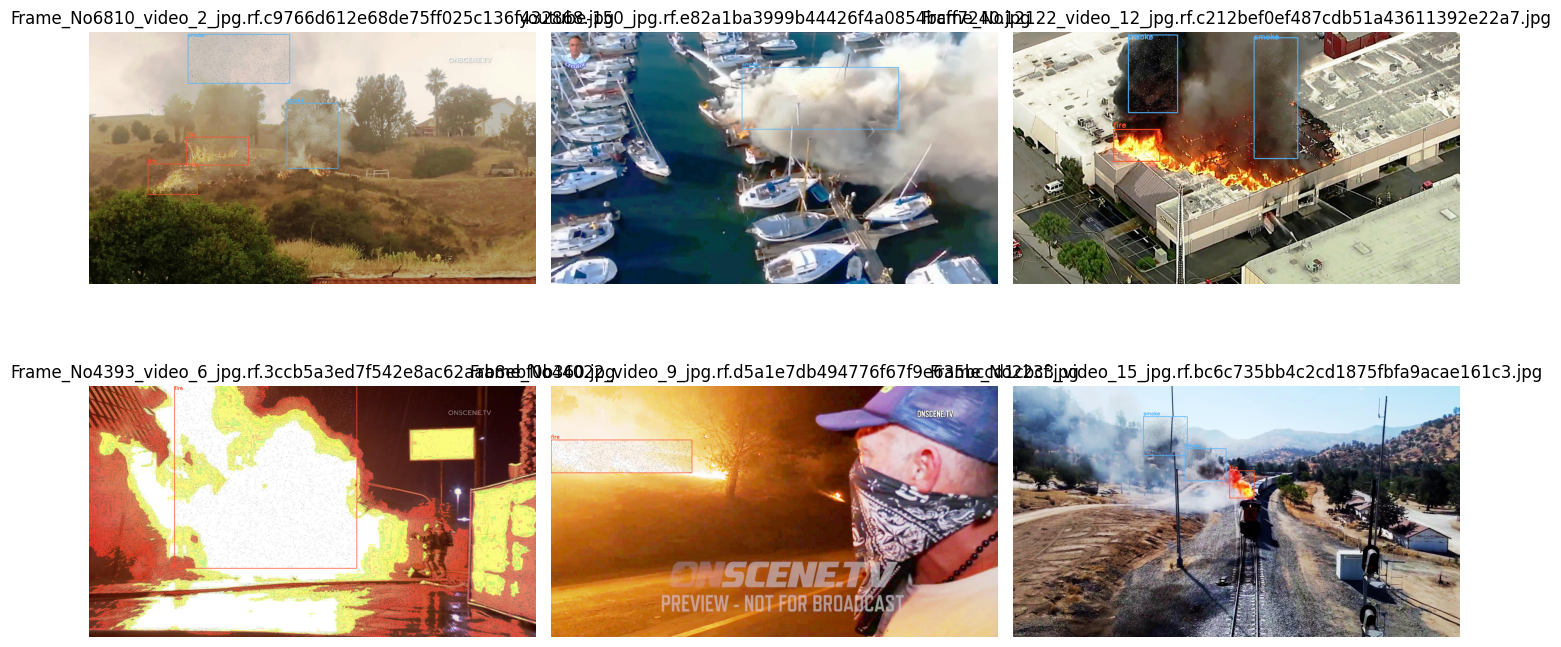

In [ ]:
def draw_yolo_boxes(image_path: Path, labels_dir: Path):
    image = cv2.imread(str(image_path))
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    h, w = image.shape[:2]
    label_path = label_for_image(image_path, labels_dir)

    for line in label_path.read_text(encoding="utf-8").splitlines():
        if not line.strip():
            continue
        cls, xc, yc, bw, bh = map(float, line.split()[:5])
        x1 = int((xc - bw / 2) * w)
        y1 = int((yc - bh / 2) * h)
        x2 = int((xc + bw / 2) * w)
        y2 = int((yc + bh / 2) * h)
        color = (255, 80, 40) if int(cls) == 0 else (80, 180, 255)
        cv2.rectangle(image, (x1, y1), (x2, y2), color, 2)
        cv2.putText(image, CLASS_NAMES[int(cls)], (x1, max(20, y1 - 6)), cv2.FONT_HERSHEY_SIMPLEX, 0.7, color, 2)
    return image

sample_images = [
    p for p in collect_images(TRAIN_IMAGES_DIR)
    if label_for_image(p, TRAIN_LABELS_DIR).read_text(encoding="utf-8").strip()
]
sample_images = random.sample(sample_images, min(6, len(sample_images)))

plt.figure(figsize=(14, 8))
for i, img_path in enumerate(sample_images, 1):
    plt.subplot(2, 3, i)
    plt.imshow(draw_yolo_boxes(img_path, TRAIN_LABELS_DIR))
    plt.title(img_path.name)
    plt.axis("off")
plt.tight_layout()


## Yolo Обучение


In [ ]:
import torch
print(torch.cuda.is_available())

True


In [ ]:
model = YOLO("yolov8n.pt")

train_results = model.train(
    data="/content/data_8k.yaml",
    epochs=35,
    imgsz=512,
    batch=64,
    patience=15,
    workers=0,
    project=str(ROOT / "runs"),
    name="fire_smoke_yolov8n",
    exist_ok=True,
)

Ultralytics 8.4.53 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=64, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/data_8k.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=35, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=512, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=fire_smoke_yolov8n, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=